# 01 · Data Audit & EDA — Dunnhumby *The Complete Journey*

**Goal of this notebook (Phase 0):**

1. Load all 8 raw tables and record their shape / schema.
2. Audit each table: missing values, duplicates, key cardinality, value ranges.
3. Check referential integrity between tables (the implied star schema).
4. Establish the core facts we will build on: time span, households, products,
   baskets, spend.
5. First-look EDA: spend, basket size, category mix, repeat-purchase behaviour,
   campaign / coupon coverage.
6. Write a short data-quality findings list to `reports/`.

Nothing here is modelling — this is the "know your data before you touch it" pass.

### The tables

| file | grain | role |
|---|---|---|
| `transaction_data` | one product line within a basket | fact |
| `product` | one product | dimension |
| `hh_demographic` | one household (subset only) | dimension |
| `campaign_desc` | one campaign | dimension |
| `campaign_table` | household × campaign received | bridge |
| `coupon` | coupon × product × campaign | dimension |
| `coupon_redempt` | household × coupon redemption event | fact |
| `causal_data` | product × store × week promo exposure | fact |

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

# repo root = parent of notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("raw dir:", RAW)
print(sorted(p.name for p in RAW.glob("*.csv")))

raw dir: /home/cleave/dev/fmcg-recommender/data/raw
['campaign_desc.csv', 'campaign_table.csv', 'causal_data.csv', 'coupon.csv', 'coupon_redempt.csv', 'hh_demographic.csv', 'product.csv', 'transaction_data.csv']


In [2]:
# Load everything. All small except causal_data (~36.7M rows / 664 MB) which we
# read with narrow dtypes so it stays ~700 MB in RAM instead of several GB.
FILES = {
    "transactions": "transaction_data.csv",
    "product": "product.csv",
    "demographic": "hh_demographic.csv",
    "campaign_desc": "campaign_desc.csv",
    "campaign_table": "campaign_table.csv",
    "coupon": "coupon.csv",
    "coupon_redempt": "coupon_redempt.csv",
}
raw = {}
for name, fn in FILES.items():
    raw[name] = pd.read_csv(RAW / fn)
    print(f"{name:16s} {str(raw[name].shape):>20s}   {fn}")

raw["causal"] = pd.read_csv(
    RAW / "causal_data.csv",
    dtype={"PRODUCT_ID": "int32", "STORE_ID": "int32", "WEEK_NO": "int16",
           "display": "category", "mailer": "category"},
)
print(f"{'causal':16s} {str(raw['causal'].shape):>20s}   causal_data.csv")

transactions            (2595732, 12)   transaction_data.csv
product                    (92353, 7)   product.csv
demographic                  (801, 8)   hh_demographic.csv
campaign_desc                 (30, 4)   campaign_desc.csv
campaign_table              (7208, 3)   campaign_table.csv
coupon                    (124548, 3)   coupon.csv
coupon_redempt              (2318, 4)   coupon_redempt.csv
causal                  (36786524, 5)   causal_data.csv


In [3]:
# Normalise column names to snake_case lower for our sanity.
for name, df in raw.items():
    df.columns = [c.strip().lower() for c in df.columns]
raw["transactions"].head()

,household_key,basket_id,day,product_id,quantity,sales_value,store_id,retail_disc,trans_time,week_no,coupon_disc,coupon_match_disc
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


## 1 · Per-table schema & head

In [4]:
def schema(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_null": df.isna().sum(),
        "pct_null": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    })
    out["example"] = [df[col].dropna().iloc[0] if df[col].notna().any() else None
                      for col in df.columns]
    return out

for name, df in raw.items():
    print(f"\n=== {name}  {df.shape} ===")
    display(schema(df))


=== transactions  (2595732, 12) ===


,dtype,n_null,pct_null,n_unique,example
household_key,int64,0,0.0,2500,2.375000e+03
basket_id,int64,0,0.0,276484,2.698485e+10
day,int64,0,0.0,711,1.000000e+00
product_id,int64,0,0.0,92339,1.004906e+06
quantity,int64,0,0.0,11746,1.000000e+00
sales_value,float64,0,0.0,5502,1.390000e+00
store_id,int64,0,0.0,582,3.640000e+02
retail_disc,float64,0,0.0,2414,-6.000000e-01
trans_time,int64,0,0.0,1440,1.631000e+03
week_no,int64,0,0.0,102,1.000000e+00



=== product  (92353, 7) ===


,dtype,n_null,pct_null,n_unique,example
product_id,int64,0,0.0,92353,25671
manufacturer,int64,0,0.0,6476,2
department,object,0,0.0,44,GROCERY
brand,object,0,0.0,2,National
commodity_desc,object,0,0.0,308,FRZN ICE
sub_commodity_desc,object,0,0.0,2383,ICE - CRUSHED/CUBED
curr_size_of_product,object,0,0.0,4345,22 LB



=== demographic  (801, 8) ===


...

,dtype,n_null,pct_null,n_unique,example
coupon_upc,int64,0,0.0,1135,10000089061
product_id,int64,0,0.0,44133,27160
campaign,int64,0,0.0,30,4



=== coupon_redempt  (2318, 4) ===


,dtype,n_null,pct_null,n_unique,example
household_key,int64,0,0.0,434,1
day,int64,0,0.0,328,421
coupon_upc,int64,0,0.0,556,10000085364
campaign,int64,0,0.0,30,8



=== causal  (36786524, 5) ===


,dtype,n_null,pct_null,n_unique,example
product_id,int32,0,0.0,68377,26190
store_id,int32,0,0.0,115,286
week_no,int16,0,0.0,93,70
display,category,0,0.0,10,0
mailer,category,0,0.0,11,A


## 2 · Duplicates & key candidates

In [5]:
key_guesses = {
    "transactions": ["household_key", "basket_id", "product_id"],
    "product": ["product_id"],
    "demographic": ["household_key"],
    "campaign_desc": ["campaign"],
    "campaign_table": ["household_key", "campaign"],
    "coupon": ["coupon_upc", "product_id", "campaign"],
    "coupon_redempt": ["household_key", "coupon_upc", "campaign", "day"],
    "causal": ["product_id", "store_id", "week_no"],
}
for name, keys in key_guesses.items():
    df = raw[name]
    keys = [k for k in keys if k in df.columns]
    dup_rows = df.duplicated().sum()
    dup_key = df.duplicated(subset=keys).sum() if keys else np.nan
    print(f"{name:16s} full-row dups={dup_rows:>7d}   dups on {keys} = {dup_key}")

transactions     full-row dups=      0   dups on ['household_key', 'basket_id', 'product_id'] = 0
product          full-row dups=      0   dups on ['product_id'] = 0
demographic      full-row dups=      0   dups on ['household_key'] = 0
campaign_desc    full-row dups=      0   dups on ['campaign'] = 0
campaign_table   full-row dups=      0   dups on ['household_key', 'campaign'] = 0
coupon           full-row dups=   5164   dups on ['coupon_upc', 'product_id', 'campaign'] = 5164
coupon_redempt   full-row dups=      0   dups on ['household_key', 'coupon_upc', 'campaign', 'day'] = 0
causal           full-row dups=      0   dups on ['product_id', 'store_id', 'week_no'] = 15245


## 3 · Referential integrity

Every `product_id` / `household_key` that appears in a fact table should resolve
to its dimension — except `hh_demographic`, which Dunnhumby only provides for a
subset of households (this is expected and matters for cold-start framing).

In [6]:
def coverage(child, child_col, parent, parent_col):
    c, p = raw[child][child_col], raw[parent][parent_col]
    missing = set(c.dropna().unique()) - set(p.dropna().unique())
    n_child = c.nunique()
    print(f"{child}.{child_col} -> {parent}.{parent_col}: "
          f"{n_child - len(missing)}/{n_child} resolve "
          f"({len(missing)} orphan ids)")

coverage("transactions", "product_id", "product", "product_id")
coverage("transactions", "household_key", "demographic", "household_key")
coverage("causal", "product_id", "product", "product_id")
coverage("coupon", "product_id", "product", "product_id")
coverage("coupon_redempt", "household_key", "campaign_table", "household_key")
coverage("campaign_table", "campaign", "campaign_desc", "campaign")

n_hh_txn = raw["transactions"]["household_key"].nunique()
n_hh_demo = raw["demographic"]["household_key"].nunique()
print(f"\nhouseholds with transactions : {n_hh_txn}")
print(f"households with demographics : {n_hh_demo} "
      f"({n_hh_demo / n_hh_txn:.0%} of transacting households)")

transactions.product_id -> product.product_id: 92339/92339 resolve (0 orphan ids)
transactions.household_key -> demographic.household_key: 801/2500 resolve (1699 orphan ids)
causal.product_id -> product.product_id: 68377/68377 resolve (0 orphan ids)
coupon.product_id -> product.product_id: 44133/44133 resolve (0 orphan ids)
coupon_redempt.household_key -> campaign_table.household_key: 434/434 resolve (0 orphan ids)
campaign_table.campaign -> campaign_desc.campaign: 30/30 resolve (0 orphan ids)

households with transactions : 2500
households with demographics : 801 (32% of transacting households)


## 4 · Core facts we build on

In [7]:
t = raw["transactions"]
# DAY is an integer day index (1..711); WEEK_NO is 1..102. No calendar dates given.
facts = {
    "date span (day index)": (int(t["day"].min()), int(t["day"].max())),
    "date span (week_no)": (int(t["week_no"].min()), int(t["week_no"].max())),
    "n households": t["household_key"].nunique(),
    "n baskets": t["basket_id"].nunique(),
    "n products purchased": t["product_id"].nunique(),
    "n stores": t["store_id"].nunique(),
    "n transaction lines": len(t),
    "total sales_value": round(t["sales_value"].sum(), 2),
    "total quantity": int(t["quantity"].sum()),
}
for k, v in facts.items():
    print(f"{k:26s} {v}")

# sanity: lines per basket, baskets per household
lpb = t.groupby("basket_id").size()
bph = t.groupby("household_key")["basket_id"].nunique()
print("\nlines per basket   ", lpb.describe(percentiles=[.5, .9, .99]).round(1).to_dict())
print("baskets per household", bph.describe(percentiles=[.5, .9, .99]).round(1).to_dict())

date span (day index)      (1, 711)
date span (week_no)        (1, 102)
n households               2500
n baskets                  276484
n products purchased       92339
n stores                   582
n transaction lines        2595732
total sales_value          8057463.08
total quantity             260685622

lines per basket    {'count': 276484.0, 'mean': 9.4, 'std': 12.3, 'min': 1.0, '50%': 5.0, '90%': 24.0, '99%': 58.0, 'max': 168.0}
baskets per household {'count': 2500.0, 'mean': 110.6, 'std': 115.7, 'min': 1.0, '50%': 79.0, '90%': 229.1, '99%': 553.1, 'max': 1300.0}


## 5 · First-look EDA

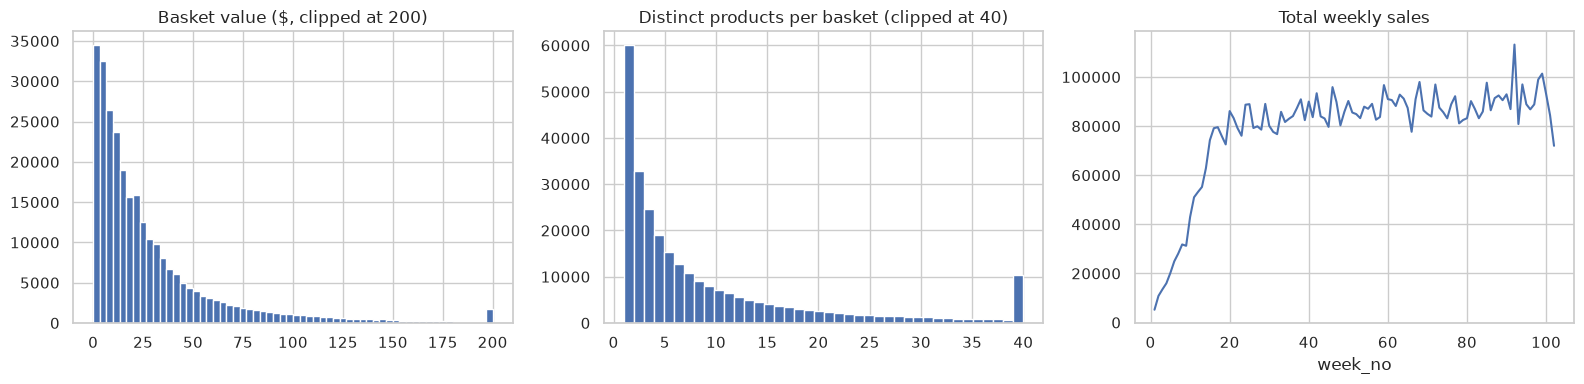

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

t.groupby("basket_id")["sales_value"].sum().clip(upper=200).hist(bins=60, ax=ax[0])
ax[0].set_title("Basket value ($, clipped at 200)")

lpb.clip(upper=40).hist(bins=40, ax=ax[1])
ax[1].set_title("Distinct products per basket (clipped at 40)")

weekly = t.groupby("week_no")["sales_value"].sum()
weekly.plot(ax=ax[2])
ax[2].set_title("Total weekly sales")
plt.tight_layout()
plt.savefig(FIG / "01_basket_and_weekly.png", dpi=110)
plt.show()

,sales,lines,sales_share
department,,,
GROCERY,4093814.14,1646076,50.8
DRUG GM,1055358.03,277232,13.1
PRODUCE,557452.11,257290,6.9
MEAT,548786.81,88416,6.8
KIOSK-GAS,544222.28,22059,6.8
MEAT-PCKGD,412436.77,111957,5.1
DELI,260866.51,62787,3.2
PASTRY,121739.86,38179,1.5
MISC SALES TRAN,119960.04,6050,1.5


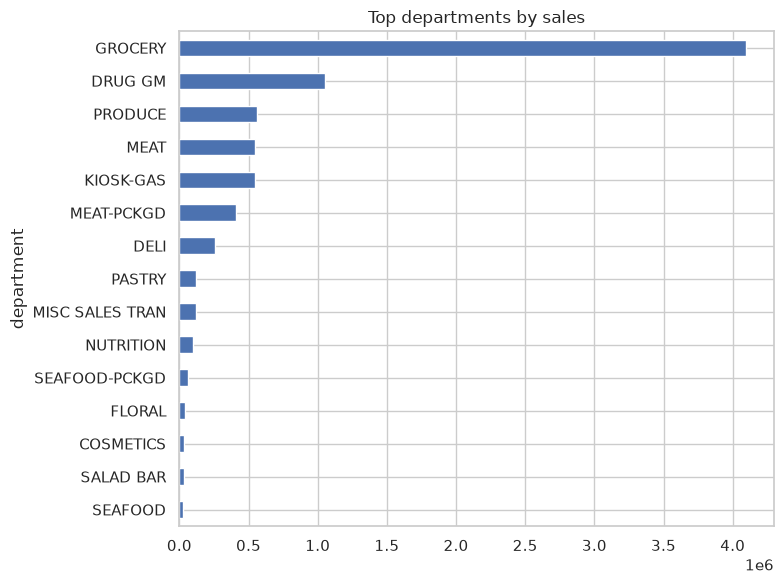

In [9]:
# Category mix via the product hierarchy
p = raw["product"]
tp = t.merge(p[["product_id", "department", "commodity_desc"]], on="product_id", how="left")

dept = (tp.groupby("department")
          .agg(sales=("sales_value", "sum"), lines=("product_id", "size"))
          .sort_values("sales", ascending=False))
dept["sales_share"] = (dept["sales"] / dept["sales"].sum() * 100).round(1)
display(dept.head(15))

ax = dept["sales"].head(15).iloc[::-1].plot.barh(figsize=(8, 6))
ax.set_title("Top departments by sales")
plt.tight_layout()
plt.savefig(FIG / "01_department_sales.png", dpi=110)
plt.show()

share of (household, product) pairs bought in >1 basket: 26.9%
share of transaction lines that are repeat purchases: 45.9%


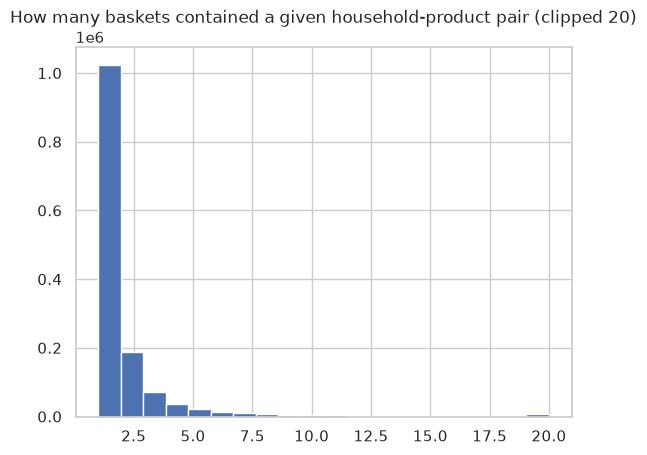

In [10]:
# Repeat-purchase behaviour — the thing that makes grocery recommendation different.
# For each (household, product): how many separate baskets contained it?
hp = (t.groupby(["household_key", "product_id"])["basket_id"]
        .nunique().rename("n_baskets").reset_index())
share_repeat = (hp["n_baskets"] > 1).mean()
print(f"share of (household, product) pairs bought in >1 basket: {share_repeat:.1%}")

# Of all purchase events, how many are of a product the household already bought before?
t_sorted = t.sort_values(["household_key", "day"])
first_seen = t_sorted.groupby(["household_key", "product_id"])["day"].transform("min")
repeat_line_share = (t_sorted["day"] > first_seen).mean()
print(f"share of transaction lines that are repeat purchases: {repeat_line_share:.1%}")

hp["n_baskets"].clip(upper=20).hist(bins=20)
plt.title("How many baskets contained a given household-product pair (clipped 20)")
plt.savefig(FIG / "01_repeat_purchase.png", dpi=110)
plt.show()

In [11]:
# Campaign / coupon coverage — the raw material for Phase 5 (uplift).
ct, cd = raw["campaign_table"], raw["campaign_desc"]
cr = raw["coupon_redempt"]

print("distinct campaigns              :", cd["campaign"].nunique())
print("campaign types                  :", cd["description"].value_counts().to_dict())
print("households that received >=1 campaign:",
      ct["household_key"].nunique(),
      f"({ct['household_key'].nunique() / n_hh_txn:.0%})")
print("campaigns received per household :",
      ct.groupby("household_key")["campaign"].nunique()
        .describe(percentiles=[.5, .9]).round(1).to_dict())
print("households with >=1 coupon redemption:", cr["household_key"].nunique())
print("total coupon redemption events   :", len(cr))

distinct campaigns              : 30
campaign types                  : {'TypeB': 19, 'TypeC': 6, 'TypeA': 5}
households that received >=1 campaign: 1584 (63%)
campaigns received per household : {'count': 1584.0, 'mean': 4.6, 'std': 3.0, 'min': 1.0, '50%': 4.0, '90%': 9.0, 'max': 17.0}
households with >=1 coupon redemption: 434
total coupon redemption events   : 2318


## 6 · Data-quality findings

_Fill this in as we go, then mirror the final list into `reports/data_quality.md`._

- **No calendar dates** — only `day` (1–711) and `week_no` (1–102) integer indices.
  All temporal splits use `week_no`.
- **Demographics cover only a subset of households** — cold-start / content-based
  models must not assume demographics exist.
- `sales_value` is *net* of `retail_disc` / `coupon_disc`; watch for zero and
  negative values (returns / full-coupon items).
- Products can appear in `transactions` without a `product` row (orphans) — decide
  keep vs drop.
- Campaigns were **not randomly assigned** — critical caveat for uplift modelling.

### Next notebook
`02_build_star_schema.ipynb` — clean, type, and materialise the modelling tables
(`baskets`, `interactions`, `product_dim`, `household_dim`) to `data/processed/`.